# The HiggsML Challege

For the last coding assignment, you'll need to implement a neural network.We'll look at a relatively simple binary classification problem.

**Tasks**:

1. Remember: scale your data appropriately

2. Decide on a testing strategy (a simple test/train split? a CV strategy? set a test set aside to be looked at at the very end?)

3. Decide your optimization metric.

4. Write down your neural network. I would start from a fully connected, multi-layer perceptron. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning.

5. Optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best.  Do your best now to optimize the network architecture. Be creative!

6. Report on the perfomance of the network on the test set; report other metrics that have not been optimized.

**A few tips**:
- In scikit-learn, remember that you can utilize all availables cores on your machine with `n_jobs=-1`. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
- If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
- On cross validation, for scikit learn we've seen how to use `GridSearchCV` already. For Tensorflow, there's a really cool tool called [Tensorboard](https://www.tensorflow.org/tensorboard)

**Datasets**:

Branching out of astrophysics, let's mess around with a dataset of simulated but very realistic events from the ATLAS particle collider at CERN.

- Data are at `solutions/higgs.tar.gz` (you need to uncompress with `tar -czvf`)
- There are $N_{\\rm samples} = 2.5\\times 10^5$ entries with $N_{\\rm features}=30$ measured features each.
- The label is `s` (source) vs `b` (background).
- For some background on both the physics and the dataset see [this document](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf); includes a description of the   features and how data have been padded (-999) for missing values.
- This dataset was part of a major challenge that run on Kaggle in 2014: https://higgsml.ijclab.in2p3.fr/

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import keras_tuner as kt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from tensorflow import keras

from keras_tuner.tuners import RandomSearch

## Dataset

In [13]:
# Load CSV
df = pd.read_csv("higgs.csv")

In [14]:
# Drop non-feature columns
event_ids = df['EventId']
weights = df['Weight']
labels = df['Label'].map({'s': 1, 'b': 0})
X = df.drop(['EventId', 'Weight', 'Label'], axis=1)

# Replace missing values (-999.0) with NaN, then impute
X.replace(-999.0, np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

print(X.shape)

(250000, 30)


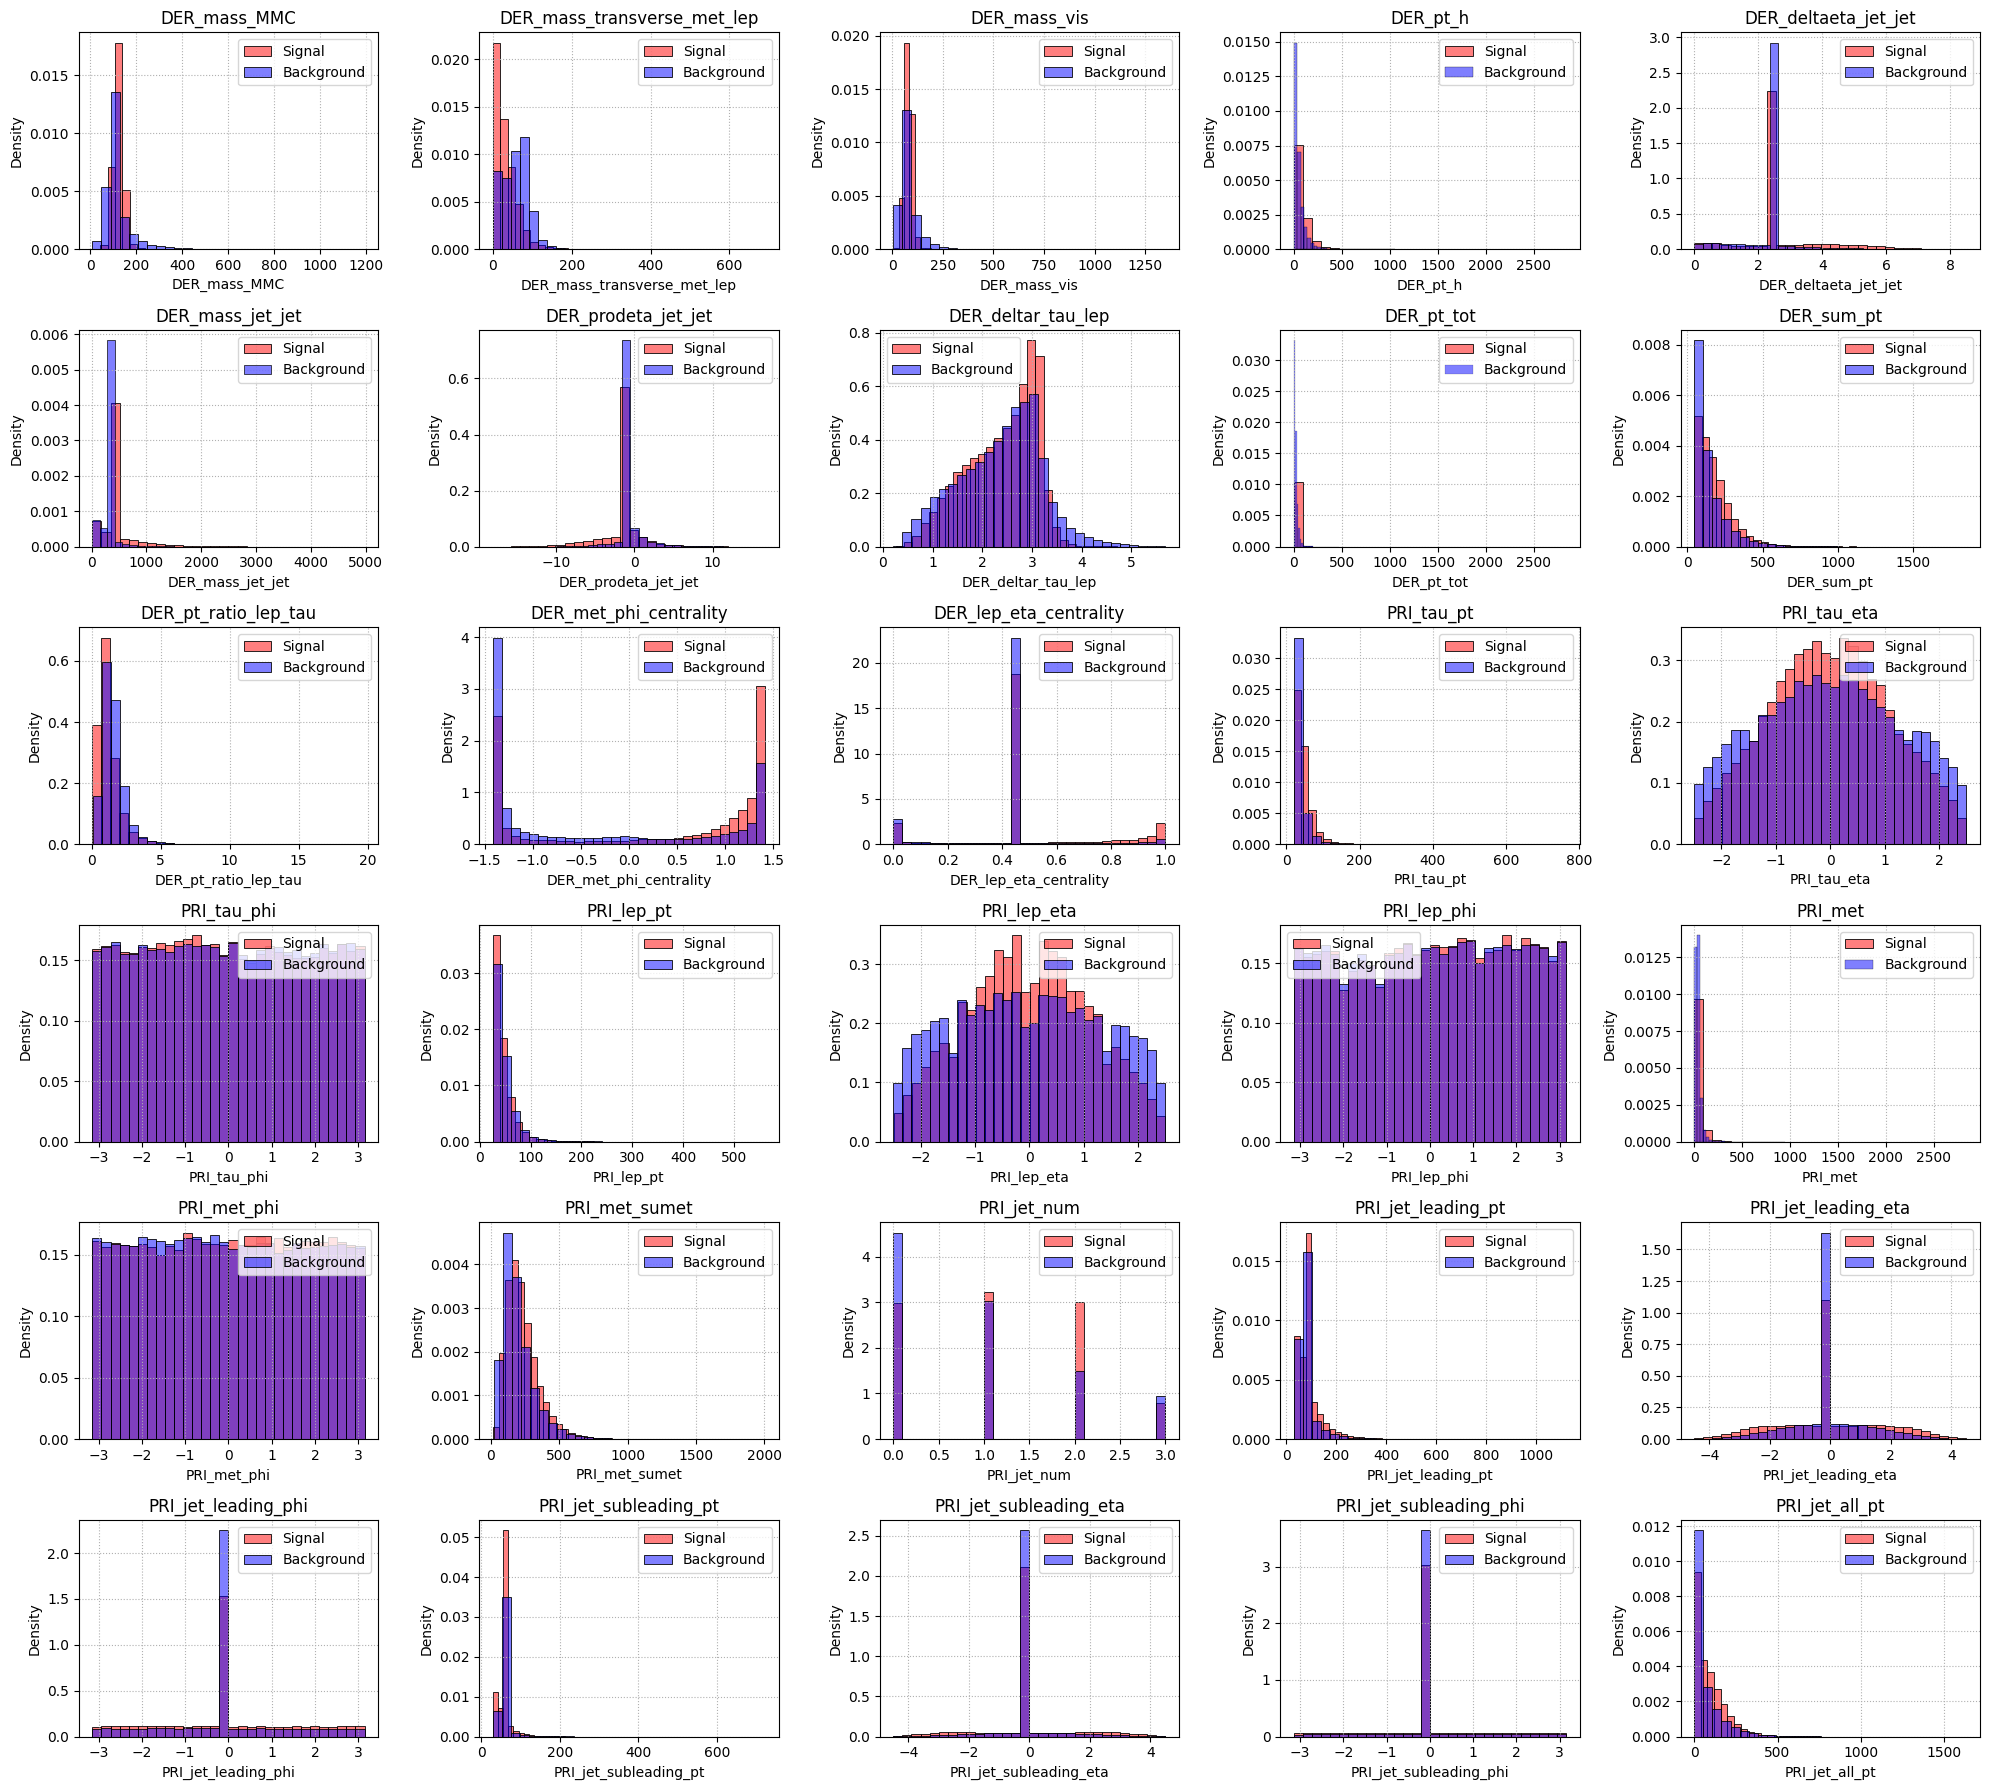

In [15]:
# Plot the first features
max_features = 30
n_cols = 5

features = X.columns[:max_features]  # Limit to first few for clarity
n_rows = int(np.ceil(len(features) / n_cols))
plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(X[col][labels == 1], color='r', label='Signal', stat='density', bins=30, alpha=0.5)
    sns.histplot(X[col][labels == 0], color='b', label='Background', stat='density', bins=30, alpha=0.5)
    plt.title(col)
    plt.legend()
    plt.grid(linestyle=':')

plt.tight_layout()
plt.show()

From these plots we can see that the most important feature is DER_mass_transverse_met_lep.

This feature is the transverse mass computed between the reconstructed lepton and the missing transverse energy (MET) as 

$$m_T = \sqrt{2 p^l_T E^{miss}_T[1 - cos(\Delta \phi)]}$$

where:
- $p^l_T$ is the transverse momentum of the lepton
- $E^{miss}_T$ is the missing transverse nenergy (MET)
- $\Delta \phi$ is the azimuthal angle difference between the lepton and the MET

Let's see it more in detail.

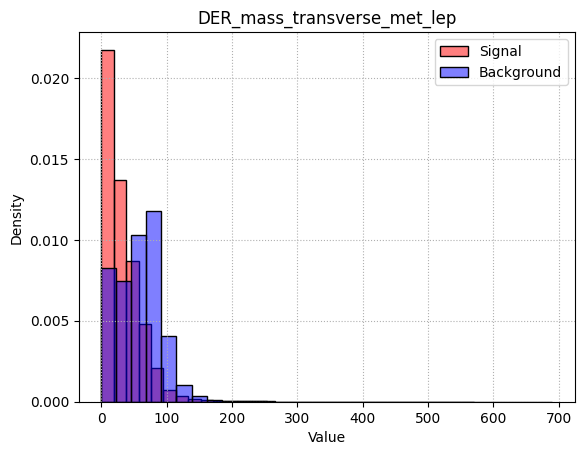

In [16]:
# DER_mass_transverse_met_lep Plot
sns.histplot(X['DER_mass_transverse_met_lep'][labels == 1], color='r', label='Signal', stat='density', bins=30, alpha=0.5)
sns.histplot(X['DER_mass_transverse_met_lep'][labels == 0], color='b', label='Background', stat='density', bins=30, alpha=0.5)
plt.title("DER_mass_transverse_met_lep")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(linestyle=':')
plt.show()


As we can see in this featrure the signal peak can be easily separate from the background because of the different shapes of the two distribution. The difference in shape is the reason why this variable can be considered a powerful discriminant, indeed the classifier learn that events with $m_T$ near the physical endpoint are more likely to be Higgs-like signal. 

In [17]:
# Split the dataset into training set (80%) and test set (20%)
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, labels, weights, test_size=0.2, stratify=labels, random_state=42)

# Sclae the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## ML Analysis

In [18]:
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train.shape[1],)))

    # Tune number of layers
    for i in range(hp.Int('num_layers', 1, 4)):
        model.add(keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=64, max_value=256, step=32),
            activation='relu'))
        # Tune dropout rate
        model.add(keras.layers.Dropout(rate=hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))
    
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # Tune optimizer learning rate
    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    optimizer = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    
    return model

def ams_score(s, b, b_reg=10):

    # -----
    # s: estimated total weight of true signal events selected by your model (true positives)
    # b: estimated total weight of background events wrongly selected as signal (false positives)
    # b_reg: regularization term added to b to prevent numerical instability (e.g., log(0)); usually set to 10
    # -----
    
    # Compute the AMS score using the formula:
    # AMS = sqrt( 2 * [ (s + b + b_reg) * log(1 + s / (b + b_reg)) - s ] )
    #
    # This is a smoothed and regularized approximation of the discovery significance.

    radicand = 2 * ((s + b + b_reg) * np.log(1.0 + s / (b + b_reg)) - s)
    if radicand > 0:
        AMS = np.sqrt(radicand)
    else:
        AMS = 0

    return AMS

In [19]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_auc',
    max_trials=20,
    executions_per_trial=2,
    directory='keras_tuner_higgs_dir',
    project_name='higgsml_keras'
)

# Early stopping to speed up search
early_stop = keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)

tuner.search(X_train, y_train, epochs=30, validation_split=0.2, callbacks=[early_stop], batch_size=1024)

Trial 20 Complete [00h 02m 43s]
val_auc: 0.9030381739139557

Best val_auc So Far: 0.9094147086143494
Total elapsed time: 00h 37m 31s


In [20]:
best_model = tuner.get_best_models(num_models=1)[0]

# Train best model on full training set with early stopping
history = best_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=1024,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50


/home/alessia_pozzi/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8422 - auc: 0.9105 - loss: 0.3546 - val_accuracy: 0.8429 - val_auc: 0.9094 - val_loss: 0.3571
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8447 - auc: 0.9125 - loss: 0.3517 - val_accuracy: 0.8434 - val_auc: 0.9093 - val_loss: 0.3570
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8427 - auc: 0.9111 - loss: 0.3541 - val_accuracy: 0.8433 - val_auc: 0.9093 - val_loss: 0.3562
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8388 - auc: 0.9087 - loss: 0.3591 - val_accuracy: 0.8438 - val_auc: 0.9095 - val_loss: 0.3553
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8430 - auc: 0.9121 - loss: 0.3522 - val_accuracy: 0.8450 - val_auc: 0.9090 - val_loss: 0.3566
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8424 - auc: 0.9117 - loss: 0.3533 - val_accuracy: 0.8439 - val_auc: 0.9091 - val_loss: 0.3562
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 16m

In [21]:
# Best model's result
results = best_model.evaluate(X_test, y_test)
print(f"Test loss: {results[0]:.5f}")
print(f"Accuracy: {results[1]:.5f}")
print(f"AUC: {results[2]:.5f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8407 - auc: 0.9092 - loss: 0.3574
Test loss: 0.35644
Accuracy: 0.84108
AUC: 0.91010


In [23]:
y_pred_proba = best_model.predict(X_test).ravel()
best_ams = 0
best_threshold = 0.5

for threshold in np.linspace(0, 1, 100):  # try thresholds from 0 to 1
    selected = y_pred_proba > threshold
    s = w_test[(y_test == 1) & selected].sum() # true poitive
    b = w_test[(y_test == 0) & selected].sum() # false positive

    ams = ams_score(s, b)
    if ams > best_ams:
        best_ams = ams
        best_threshold = threshold

print(f"\n Best AMS = {best_ams:.4f} at threshold = {best_threshold:.2f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

 Best AMS = 1.5460 at threshold = 0.82


The highest AMS value at the end of competition was 3.80581, while mine is 1.5460 and I fell pretty bad :(

I will work to improve my skills in Neural Network.